<a href="https://colab.research.google.com/github/maheshisewwandisamaraweera/image-authentication-project/blob/maheshi/notebooks/Module_1_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
results = pd.read_csv(
    "/content/drive/MyDrive/image-authentication-project/results/prediction_results.csv"
)

results.head()

,Image Name,Original Category,Prediction,Confidence (%)
0,A024-034.png,Actual,Edited,68.17
1,A025-051.png,Actual,Actual,76.15
2,A003-032.png,Actual,Actual,73.48
3,A037-005.png,Actual,Actual,63.82
4,A001-010.png,Actual,Actual,69.67


In [4]:
y_true = results["Original Category"]
y_pred = results["Prediction"]

In [5]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.4515


In [6]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.5047
Recall    : 0.4515
F1 Score  : 0.4471


In [7]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
AI Generated,0.392694,0.455026,0.421569,189.000000
Actual,0.422642,0.592593,0.493392,189.000000
Edited,0.698795,0.306878,0.426471,189.000000
accuracy,0.451499,0.451499,0.451499,0.451499
macro avg,0.504710,0.451499,0.447144,567.000000
weighted avg,0.504710,0.451499,0.447144,567.000000


In [8]:
report_df.to_csv(
    "/content/drive/MyDrive/image-authentication-project/results/classification_report.csv"
)

In [9]:
labels = [
    "Actual",
    "Edited",
    "AI Generated"
]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


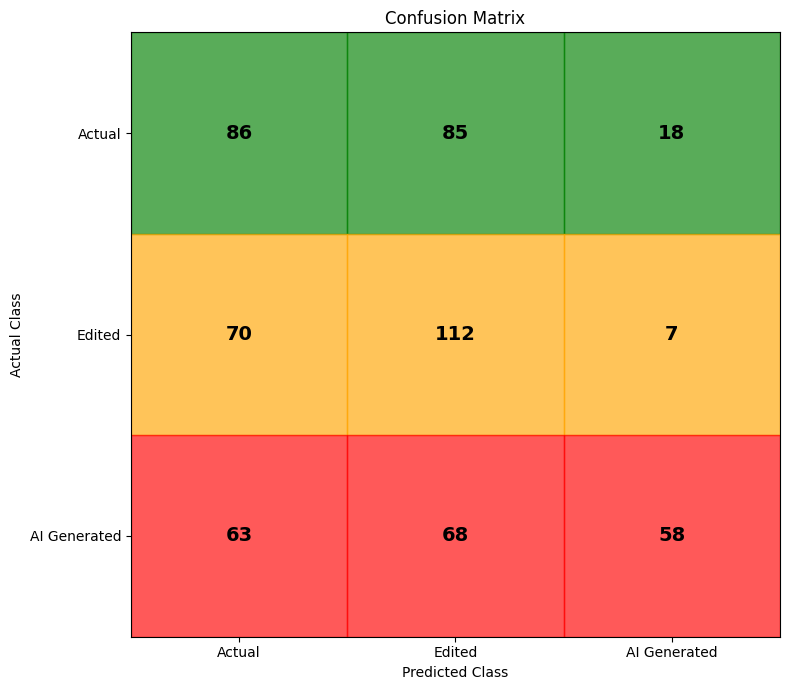

Saved: /content/drive/MyDrive/image-authentication-project/results/confusion_matrix.png


In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

from google.colab import drive
drive.mount('/content/drive')


# Class names (same order as your model)
labels = [
    "Actual",
    "Edited",
    "AI Generated"
]


# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)


# Save path
save_path = "/content/drive/MyDrive/image-authentication-project/results/confusion_matrix.png"


os.makedirs(
    os.path.dirname(save_path),
    exist_ok=True
)


# Class colors
colors = [
    "green",     # Actual row
    "orange",    # Edited row
    "red"        # AI Generated row
]


fig, ax = plt.subplots(figsize=(8,7))


# Draw colored cells
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.add_patch(
            plt.Rectangle(
                (j, i),
                1,
                1,
                color=colors[i],
                alpha=0.65
            )
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )


# Axis settings
ax.set_xlim(0, len(labels))
ax.set_ylim(len(labels), 0)

ax.set_xticks(np.arange(len(labels)) + 0.5)
ax.set_yticks(np.arange(len(labels)) + 0.5)

ax.set_xticklabels(labels, rotation=0)
ax.set_yticklabels(labels, rotation=0)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")


plt.tight_layout()


# Save image
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()

plt.close()


print("Saved:", save_path)

In [13]:
plt.savefig(
    "/content/drive/MyDrive/image-authentication-project/results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

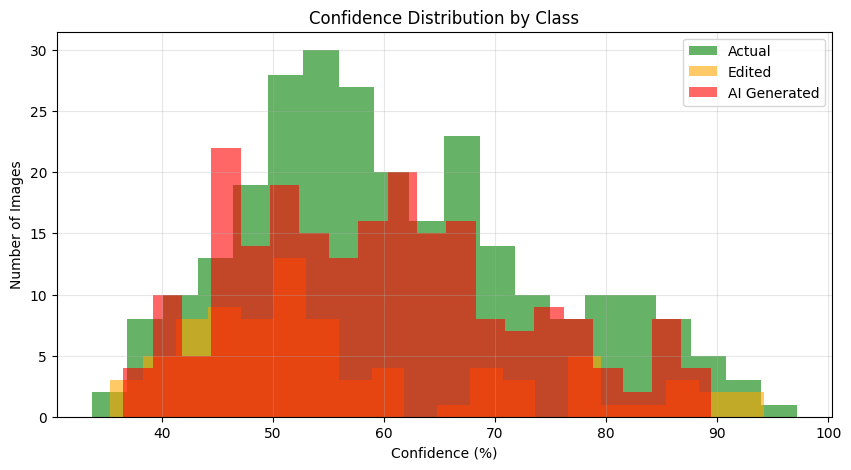

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

colors = {
    "Actual": "green",
    "Edited": "orange",
    "AI Generated": "red"
}

for label, color in colors.items():
    plt.hist(
        results[results["Prediction"] == label]["Confidence (%)"],
        bins=20,
        alpha=0.6,
        label=label,
        color=color
    )

plt.xlabel("Confidence (%)")
plt.ylabel("Number of Images")
plt.title("Confidence Distribution by Class")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

/tmp/ipykernel_3615/842314945.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


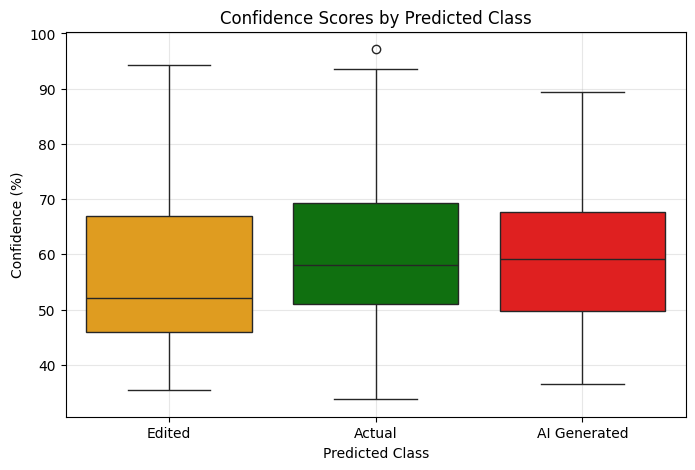

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

colors = {
    "Actual": "green",
    "Edited": "orange",
    "AI Generated": "red"
}

sns.boxplot(
    data=results,
    x="Prediction",
    y="Confidence (%)",
    palette=colors
)

plt.title("Confidence Scores by Predicted Class")
plt.xlabel("Predicted Class")
plt.ylabel("Confidence (%)")

plt.grid(alpha=0.3)

plt.show()

In [16]:
results["Prediction"].value_counts()

,count
Prediction,
Actual,265
AI Generated,219
Edited,83


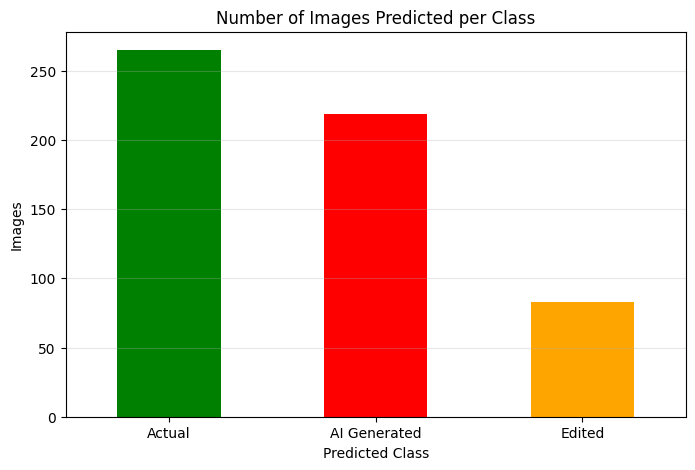

In [22]:
import matplotlib.pyplot as plt

class_counts = results["Prediction"].value_counts()

colors = {
    "Actual": "green",
    "Edited": "orange",
    "AI Generated": "red"
}

bar_colors = [
    colors[label] for label in class_counts.index
]

plt.figure(figsize=(8,5))

class_counts.plot(
    kind="bar",
    color=bar_colors
)

plt.xlabel("Predicted Class")
plt.ylabel("Images")
plt.title("Number of Images Predicted per Class")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [18]:
misclassified = results[
    results["Original Category"] != results["Prediction"]
]

misclassified

,Image Name,Original Category,Prediction,Confidence (%)
0,A024-034.png,Actual,Edited,68.17
5,A040-126.png,Actual,AI Generated,59.61
7,A023-033.png,Actual,AI Generated,57.95
8,A026-008.png,Actual,AI Generated,58.68
9,B011-102.png,Actual,AI Generated,76.89
...,...,...,...,...
558,AI_G040-445.png,AI Generated,Actual,57.78
559,AI_G031-007.png,AI Generated,Edited,65.78
561,AI_G052-133.png,AI Generated,Actual,49.48
565,AI_H020-018.png,AI Generated,Actual,71.60


In [19]:
misclassified.to_csv(
    "/content/drive/MyDrive/image-authentication-project/results/misclassified_images.csv",
    index=False
)